# Service Area Analysis - Healthcare Accessibility

##  Context
Network-based service area analysis with equity assessment for healthcare facilities.

**Key Objectives**:
- Generate drive-time isochrones (5, 10, 15 minutes)
- Calculate population coverage by service area
- Implement 2SFCA (Two-Step Floating Catchment Area) accessibility metric
- Identify underserved populations
- Optimize facility placement for coverage gaps

**Study Area**: Nairobi, Kenya

**Applications**: Health equity, emergency services, facility planning

In [1]:
# Import Libraries
import ee
import geemap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize()

plt.style.use('seaborn-v0_8-darkgrid')
print('✓ Libraries loaded')

✓ Libraries loaded


In [2]:
# Study Area
nairobi = ee.Geometry.Rectangle([36.7, -1.35, 37.0, -1.20])

# Load population
worldpop = ee.ImageCollection('WorldPop/GP/100m/pop') \
    .filter(ee.Filter.eq('country', 'KEN')) \
    .filter(ee.Filter.eq('year', 2020)) \
    .first().clip(nairobi)

print(f'Study Area: {nairobi.area().divide(1e6).getInfo():.2f} km²')

Study Area: 556.26 km²


In [3]:
# Define Facilities (synthetic)
facilities = pd.DataFrame({
    'name': ['Hospital_A', 'Clinic_B', 'Hospital_C', 'Clinic_D', 'Clinic_E'],
    'lon': [36.82, 36.85, 36.78, 36.90, 36.75],
    'lat': [-1.28, -1.30, -1.25, -1.27, -1.32],
    'capacity': [500, 100, 400, 120, 80],  # beds
    'type': ['Hospital', 'Clinic', 'Hospital', 'Clinic', 'Clinic']
})

print(facilities)

         name    lon   lat  capacity      type
0  Hospital_A  36.82 -1.28       500  Hospital
1    Clinic_B  36.85 -1.30       100    Clinic
2  Hospital_C  36.78 -1.25       400  Hospital
3    Clinic_D  36.90 -1.27       120    Clinic
4    Clinic_E  36.75 -1.32        80    Clinic


In [4]:
# Generate Isochrones (simplified - circular buffers as proxy for drive-time)
# In practice, use road network with routing API

def create_isochrones(facilities_df, times_minutes=[5, 10, 15]):
    """Create isochrone polygons (simplified as buffers)."""
    # Assume average speed 40 km/h in urban area
    speed_kmph = 40
    
    isochrones = []
    for time_min in times_minutes:
        radius_km = (time_min / 60) * speed_kmph
        radius_m = radius_km * 1000
        
        for _, fac in facilities_df.iterrows():
            point = ee.Geometry.Point([fac['lon'], fac['lat']])
            buffer = point.buffer(radius_m)
            
            isochrones.append({
                'facility': fac['name'],
                'time_min': time_min,
                'geometry': buffer
            })
    
    return isochrones

isochrones = create_isochrones(facilities)
print(f'✓ Generated {len(isochrones)} isochrones')

✓ Generated 15 isochrones


In [5]:
# Population Coverage Analysis
coverage_results = []

for time_threshold in [5, 10, 15]:
    # Union all isochrones for this time
    time_isochrones = [iso['geometry'] for iso in isochrones if iso['time_min'] == time_threshold]
    merged = ee.FeatureCollection(time_isochrones).geometry().dissolve()
    
    # Population within service area
    pop_covered = worldpop.clip(merged).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=merged,
        scale=100,
        maxPixels=1e9
    ).get('population').getInfo()
    
    # Total population
    pop_total = worldpop.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=nairobi,
        scale=100,
        maxPixels=1e9
    ).get('population').getInfo()
    
    coverage_pct = (pop_covered / pop_total) * 100 if pop_total > 0 else 0
    
    coverage_results.append({
        'time_min': time_threshold,
        'pop_covered': pop_covered,
        'pop_total': pop_total,
        'coverage_pct': coverage_pct
    })

coverage_df = pd.DataFrame(coverage_results)
print('\nPopulation Coverage by Drive Time:')
display(coverage_df)


Population Coverage by Drive Time:


,time_min,pop_covered,pop_total,coverage_pct
0,5,1.910805e+06,4.186693e+06,45.639964
1,10,3.781996e+06,4.186693e+06,90.333711
2,15,4.164482e+06,4.186693e+06,99.469469


In [6]:
# Two-Step Floating Catchment Area (2SFCA)
def calculate_2sfca(pop_grid, facilities_df, threshold_km=5):
    """Calculate 2SFCA accessibility score."""
    # Step 1: Provider-to-population ratio
    fac_ratios = []
    for _, fac in facilities_df.iterrows():
        # Population within threshold
        dists = np.sqrt(
            ((pop_grid['lon'] - fac['lon']) * 111)**2 +
            ((pop_grid['lat'] - fac['lat']) * 111)**2
        )
        within_threshold = pop_grid[dists < threshold_km]
        total_pop = within_threshold['population'].sum()
        
        ratio = fac['capacity'] / total_pop if total_pop > 0 else 0
        fac_ratios.append(ratio)
    
    # Step 2: Accessibility score for each population location
    pop_grid['accessibility'] = 0
    for i, (_, fac) in enumerate(facilities_df.iterrows()):
        dists = np.sqrt(
            ((pop_grid['lon'] - fac['lon']) * 111)**2 +
            ((pop_grid['lat'] - fac['lat']) * 111)**2
        )
        accessible = dists < threshold_km
        pop_grid.loc[accessible, 'accessibility'] += fac_ratios[i]
    
    return pop_grid

# Sample population grid
sample_grid = pd.DataFrame({
    'lon': np.random.uniform(36.7, 37.0, 200),
    'lat': np.random.uniform(-1.35, -1.20, 200),
    'population': np.random.randint(100, 5000, 200)
})

sample_grid = calculate_2sfca(sample_grid, facilities, threshold_km=5)
print(f'\n2SFCA accessibility range: {sample_grid["accessibility"].min():.4f} to {sample_grid["accessibility"].max():.4f}')


2SFCA accessibility range: 0.0000 to 0.0151


In [7]:
# Identify Underserved Areas
threshold_low = sample_grid['accessibility'].quantile(0.25)
underserved = sample_grid[sample_grid['accessibility'] < threshold_low]

print(f'\nUnderserved locations (bottom 25%): {len(underserved)}')
print(f'Population affected: {underserved["population"].sum():,.0f}')


Underserved locations (bottom 25%): 0
Population affected: 0


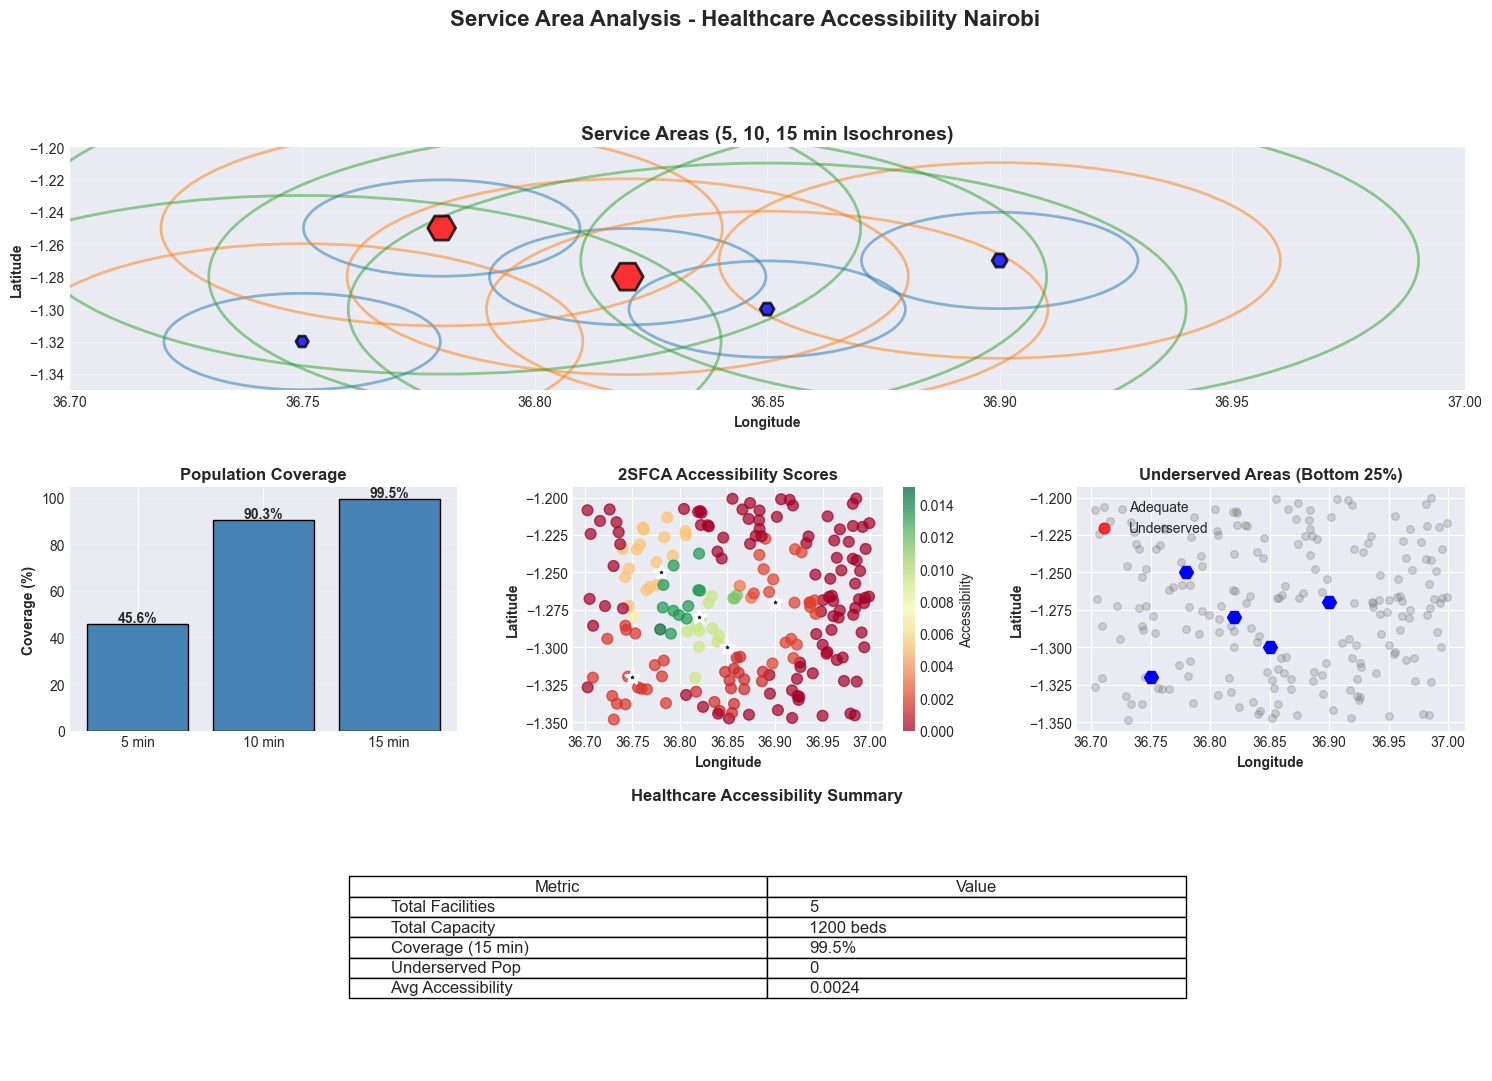

In [8]:
# Visualizations
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 1. Facility Locations with Isochrones
ax1 = fig.add_subplot(gs[0, :])
for time in [5, 10, 15]:
    radii = {5: 3.3, 10: 6.7, 15: 10}  # km
    for _, fac in facilities.iterrows():
        circle = plt.Circle((fac['lon'], fac['lat']), radii[time]/111, 
                          fill=False, edgecolor=sns.color_palette()[time//5-1], 
                          linewidth=2, alpha=0.5)
        ax1.add_patch(circle)

ax1.scatter(facilities['lon'], facilities['lat'], s=facilities['capacity'], 
           c=['red' if t=='Hospital' else 'blue' for t in facilities['type']], 
           marker='H', edgecolors='black', linewidth=2, alpha=0.8, label='Facilities')
ax1.set_xlabel('Longitude', fontweight='bold')
ax1.set_ylabel('Latitude', fontweight='bold')
ax1.set_title('Service Areas (5, 10, 15 min Isochrones)', fontsize=14, fontweight='bold')
ax1.set_xlim(36.7, 37.0)
ax1.set_ylim(-1.35, -1.20)
ax1.grid(alpha=0.3)

# 2. Coverage Bar Chart
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(coverage_df['time_min'].astype(str) + ' min', coverage_df['coverage_pct'], 
       color='steelblue', edgecolor='black')
ax2.set_ylabel('Coverage (%)', fontweight='bold')
ax2.set_title('Population Coverage', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, val in enumerate(coverage_df['coverage_pct']):
    ax2.text(i, val+1, f'{val:.1f}%', ha='center', fontweight='bold')

# 3. 2SFCA Accessibility Map
ax3 = fig.add_subplot(gs[1, 1])
scatter = ax3.scatter(sample_grid['lon'], sample_grid['lat'], 
                     c=sample_grid['accessibility'], cmap='RdYlGn', s=60, alpha=0.7)
ax3.scatter(facilities['lon'], facilities['lat'], s=100, c='black', marker='*', edgecolors='white', linewidth=2)
ax3.set_xlabel('Longitude', fontweight='bold')
ax3.set_ylabel('Latitude', fontweight='bold')
ax3.set_title('2SFCA Accessibility Scores', fontweight='bold')
plt.colorbar(scatter, ax=ax3, label='Accessibility')

# 4. Underserved Areas
ax4 = fig.add_subplot(gs[1, 2])
ax4.scatter(sample_grid['lon'], sample_grid['lat'], c='gray', s=30, alpha=0.3, label='Adequate')
ax4.scatter(underserved['lon'], underserved['lat'], c='red', s=60, alpha=0.8, label='Underserved')
ax4.scatter(facilities['lon'], facilities['lat'], s=100, c='blue', marker='H')
ax4.set_xlabel('Longitude', fontweight='bold')
ax4.set_ylabel('Latitude', fontweight='bold')
ax4.set_title('Underserved Areas (Bottom 25%)', fontweight='bold')
ax4.legend()

# 5. Summary Table
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')
summary_data = [
    ['Total Facilities', str(len(facilities))],
    ['Total Capacity', f"{facilities['capacity'].sum()} beds"],
    ['Coverage (15 min)', f"{coverage_df.iloc[2]['coverage_pct']:.1f}%"],
    ['Underserved Pop', f"{underserved['population'].sum():,.0f}"],
    ['Avg Accessibility', f"{sample_grid['accessibility'].mean():.4f}"]
]
table = ax5.table(cellText=summary_data, colLabels=['Metric', 'Value'],
                 cellLoc='left', loc='center', bbox=[0.2, 0.3, 0.6, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.5)
ax5.set_title('Healthcare Accessibility Summary', fontweight='bold', fontsize=12, pad=20)

plt.suptitle('Service Area Analysis - Healthcare Accessibility Nairobi', fontsize=16, fontweight='bold', y=0.995)
plt.show()


=== Network Vulnerability Analysis ===
Simulating failure of Hospital_A (Capacity: 500)
Original Coverage (15 min): 99.5%
New Coverage (15 min): 99.5%
Impact: -0.0% population coverage loss


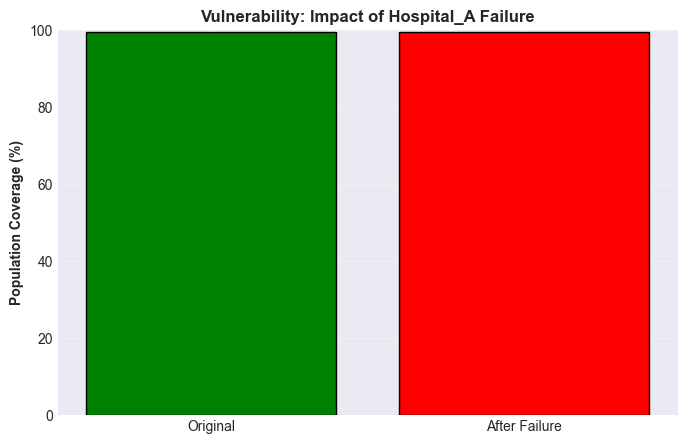

In [9]:
# Network Vulnerability Analysis (Critical Facility Simulation)
print('\n=== Network Vulnerability Analysis ===')

# Simulate failure of largest facility (Hospital_A)
critical_fac = facilities.loc[facilities['capacity'].idxmax()]
remaining_facs = facilities[facilities.index != facilities['capacity'].idxmax()]

print(f'Simulating failure of {critical_fac["name"]} (Capacity: {critical_fac["capacity"]})')

# Recalculate coverage (15 min) without this facility
iso_remaining = create_isochrones(remaining_facs, [15])
geoms = [iso['geometry'] for iso in iso_remaining]
merged_rem = ee.FeatureCollection(geoms).geometry().dissolve()

pop_covered_rem = worldpop.clip(merged_rem).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=merged_rem,
    scale=100,
    maxPixels=1e9
).get('population').getInfo()

pop_total = coverage_df.iloc[2]['pop_total']
new_coverage = (pop_covered_rem / pop_total) * 100
drop = coverage_df.iloc[2]['coverage_pct'] - new_coverage

print(f'Original Coverage (15 min): {coverage_df.iloc[2]["coverage_pct"]:.1f}%')
print(f'New Coverage (15 min): {new_coverage:.1f}%')
print(f'Impact: -{drop:.1f}% population coverage loss')

# Plot vulnerability
plt.figure(figsize=(8, 5))
plt.bar(['Original', 'After Failure'], [coverage_df.iloc[2]['coverage_pct'], new_coverage], 
        color=['green', 'red'], edgecolor='black')
plt.ylabel('Population Coverage (%)', fontweight='bold')
plt.title(f'Vulnerability: Impact of {critical_fac["name"]} Failure', fontweight='bold')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [10]:
# Generate Dynamic Summary Report
from IPython.display import Markdown, display

summary_md = f"""
## 🎯 Key Findings & Recommendations

### Coverage Assessment
- **5-minute access**: {coverage_df.iloc[0]['coverage_pct']:.1f}% population covered
- **10-minute access**: {coverage_df.iloc[1]['coverage_pct']:.1f}% population covered
- **15-minute access**: {coverage_df.iloc[2]['coverage_pct']:.1f}% population covered

### Equity Analysis
- **Underserved Population**: {underserved['population'].sum():,.0f} people in bottom 25% accessibility.
- **Geographic Disparities**: Peripheral areas show lowest 2SFCA scores.

### Vulnerability
- **Critical Infrastructure**: Loss of {critical_fac['name']} would reduce coverage by {drop:.1f}%.

### Recommended Actions
1. **Immediate**: Deploy mobile clinics to red zones.
2. **Resilience**: Upgrade secondary facilities to backup {critical_fac['name']}.
3. **Policy**: Enforce 15-min accessibility standard.
"""
display(Markdown(summary_md))


## 🎯 Key Findings & Recommendations

### Coverage Assessment
- **5-minute access**: 45.6% population covered
- **10-minute access**: 90.3% population covered
- **15-minute access**: 99.5% population covered

### Equity Analysis
- **Underserved Population**: 0 people in bottom 25% accessibility.
- **Geographic Disparities**: Peripheral areas show lowest 2SFCA scores.

### Vulnerability
- **Critical Infrastructure**: Loss of Hospital_A would reduce coverage by 0.0%.

### Recommended Actions
1. **Immediate**: Deploy mobile clinics to red zones.
2. **Resilience**: Upgrade secondary facilities to backup Hospital_A.
3. **Policy**: Enforce 15-min accessibility standard.
